In [77]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# импортируем библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

# Загружаем специальный удобный инструмент для разделения датасета:
from sklearn.model_selection import train_test_split

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [78]:
# всегда фиксируйте RANDOM_SEED, чтобы ваши эксперименты были воспроизводимы!
RANDOM_SEED = 42

In [79]:
# зафиксируем версию пакетов, чтобы эксперименты были воспроизводимы:
!pip freeze > requirements.txt

In [80]:
# Подгрузим наши данные из соревнования

#DATA_DIR = '/kaggle/input/sf-booking/'
df_train = pd.read_csv('./hotels_train.csv') # датасет для обучения
df_test = pd.read_csv('./hotels_test.csv') # датасет для предсказания
sample_submission = pd.read_csv('./submission.csv') # самбмишн

# Изучение данных

## Рассмотрим данные предоставленные для соревнования 

In [81]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

Тренировочная выборка состоит из 386803 наблюдений,
в ней содержится информация о результирующем значении - том значении, что мы хотим предстказать (reviewer_score) и 16 признаках (типов float64(4), int64(5), object(8))

In [82]:
df_train.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097


In [83]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

Тестовая выборка состоит из 128935  наблюдений,
в ней отсутствует информация о reviewer_score. Количество признаков такое же, как и в тренировочной выборке 16 признаках 

In [84]:
df_test.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443


Выборка для представления результатов состоит из 128935  наблюдений reviewer_score и id наблюдений
На основании этой выборки мы будем оценивать качество полученной модели

In [85]:
sample_submission.head(2)

,reviewer_score,id
0,8.328,488440
1,7.886,274649


In [86]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   reviewer_score  128935 non-null  float64
 1   id              128935 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 2.0 MB


In [87]:
#проверка на наличие полных дубликатов перед объединением

print('Количество дубликатов: {}'.format(df_train[df_train.duplicated()].shape[0]))
df_train = df_train.drop_duplicates()

Количество дубликатов: 307


In [88]:
# ВАЖНО! дря корректной обработки признаков объединяем трейн и тест в один датасет
df_train['sample'] = 1 # помечаем где у нас трейн
df_test['sample'] = 0 # помечаем где у нас тест
df_test['reviewer_score'] = 0 # в тесте у нас нет значения reviewer_score, мы его должны предсказать, по этому пока просто заполняем нулями

#data = df_test
#data.append(df_train, sort=False).reset_index(drop=True) # объединяем

#предложенный в бейзлайне не отработал, поэтому объединим с помощью concat
data = pd.concat([df_test, df_train],    # Combine vertically
                          ignore_index = True,
                         sort = False)

In [89]:
data.head(3)
#data.tail(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng,sample,reviewer_score
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102,0,0.0
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443,0,0.0
2,Mallorca 251 Eixample 08008 Barcelona Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,2.161520,0,0.0


In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   review_date                                 515431 non-null  object 
 3   average_score                               515431 non-null  float64
 4   hotel_name                                  515431 non-null  object 
 5   reviewer_nationality                        515431 non-null  object 
 6   negative_review                             515431 non-null  object 
 7   review_total_negative_word_counts           515431 non-null  int64  
 8   total_number_of_reviews                     515431 non-null  int64  
 9   positive_review                             515431 non-null  object 
 

In [91]:
#быстро проанализируем данные c ProfileReport и далее перейдем к более детальному анализу
from ydata_profiling import ProfileReport
profile = ProfileReport(data, title="BOOKING analitical preview")

In [92]:
#profile.to_file("BOOKING_analitical_preview.html")

In [93]:
#profile

In [94]:
#sns.pairplot(data)

In [95]:
data.columns

Index(['hotel_address', 'additional_number_of_scoring', 'review_date',
       'average_score', 'hotel_name', 'reviewer_nationality',
       'negative_review', 'review_total_negative_word_counts',
       'total_number_of_reviews', 'positive_review',
       'review_total_positive_word_counts',
       'total_number_of_reviews_reviewer_has_given', 'tags',
       'days_since_review', 'lat', 'lng', 'sample', 'reviewer_score'],
      dtype='object')

Первоначальная версия датасета содержит 17 полей со следующей информацией:

hotel_address — адрес отеля;
review_date — дата, когда рецензент разместил соответствующий отзыв;
average_score — средний балл отеля, рассчитанный на основе последнего комментария за последний год;
hotel_name — название отеля;
reviewer_nationality — страна рецензента;
negative_review — отрицательный отзыв, который рецензент дал отелю;
review_total_negative_word_counts — общее количество слов в отрицательном отзыв;
positive_review — положительный отзыв, который рецензент дал отелю;
review_total_positive_word_counts — общее количество слов в положительном отзыве.
reviewer_score — оценка, которую рецензент поставил отелю на основе своего опыта;
total_number_of_reviews_reviewer_has_given — количество отзывов, которые рецензенты дали в прошлом;
total_number_of_reviews — общее количество действительных отзывов об отеле;
tags — теги, которые рецензент дал отелю;
days_since_review — количество дней между датой проверки и датой очистки;
additional_number_of_scoring — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.
lat — географическая широта отеля;
lng — географическая долгота отеля.

На основании первичного анализа сформулирую основной план работ над признаками

* 'hotel_address' - 1493 уникальных названий, на 1 больше чем названий отелей)), выделилим из этого поля как минимум страну (можно еще выделить город, но предположу, что тогда увидим супер корреляцию с долготой и широтой (lat and lng), поэтому делать этого не буду в первом приближении),

* 'additional_number_of_scoring' имеет высокую корреляцию с total_number_of_reviews поэтому оставим один из этих признаков, но надо проанализировать данные, чтобы выбрать какой оставить. на первый взгляд не понятен смысл данного признака, признак total_number_of_reviews более понятен

* 'review_date' - равномерно распределенный признак, 731 уникальное значение, может попробовать создать признак актуальности review, вычтем из максимальной даты дату отзыва и попробуем включить в модель,
       
* 'average_score'- числовой признак, без пропусков и нулей, будет использоваться в построении моделей, 

* 'hotel_name' - 1492 уникальных названий, без пропусков. Честно говоря, не знаю, что можно сделать с этим попробуем перевести данное поле в кол-во слов  и включить в модель, 

* 'reviewer_nationality'- 227 уникальных значений. Самые популярные страны это UK - 47,55% и USA = 6,87% из из всего числа наблюдений, каких-то идей с его анализом у меня нет, поэтому пока исключу,

* 'negative_review'- на основании данного признака посчитаю кол-во слов в отзыве и удалю, 

* 'review_total_negative_word_counts' - у поля какие-то странные значения, пересчитаю самостоятельно на основании признака 'negative_review', этот удалю,

* 'total_number_of_reviews' имеет высокую корреляцию с 'additional_number_of_scoring' поэтому оставим один из этих признаков

* 'positive_review',  на основании данного признака посчитаю кол-во слов в отзыве и удалю, 

* 'review_total_positive_word_counts' - - у поля какие-то странные значения, пересчитаю самостоятельно на основании 'positive_review' , этот удалю,

* 'total_number_of_reviews_reviewer_has_given' числовой признак, без пропусков и нулей, будет использоваться в построении моделей, но надо проанализировать наличие выбросов - макс значение 354, а 95ый квартиль - 26,  

* 'tags' - проанализирую и разобъю теги на категории, а далее закодируем,
       
* 'days_since_review'-  переведу в числовой признак и включим в модель,

* 'lat' - буду использовать, но надо заполнить пустые значения, попробуем сделать это на основании того, в какой стране/городе находится отель и задать ему нужные параметры 

* 'lng'- буду использовать, но надо заполнить пустые значения, , попробуем сделать это на основании того, в какой стране/городе находится отель и задать ему нужные параметры 


In [96]:
# посчитала доп информацию по признаку hotel_name
UK_counts = round(data[data['reviewer_nationality'] == ' United Kingdom ']['reviewer_nationality'].count()/data['reviewer_nationality'].count()*100,2)
US_counts = round(data[data['reviewer_nationality'] == ' United States of America ']['reviewer_nationality'].count()/data['reviewer_nationality'].count()*100,2)

display(UK_counts, US_counts )

47.57

6.87

## Первичная очистка данных
(повторю данный пункт после детальной обработки признаков)

In [97]:
#ранее мы видели где есть пропуски, подтверждаем их наличие только в 2 признаках
#проверка на наличие пропусков
cols_null_percent = data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

lat    0.634032
lng    0.634032
dtype: float64

Разберемся с пропусками при детальном анализе

In [98]:
#проверка на наличие неинформативных признаков

#список неинформативных признаков
low_information_cols = [] 

#цикл по всем столбцам
for col in data.columns:
    #наибольшая относительная частота в признаке
    top_freq = data[col].value_counts(normalize=True).max()
    #доля уникальных значений от размера признака
    nunique_ratio = data[col].nunique() / data[col].count()
    # сравниваем наибольшую частоту с порогом
    if top_freq > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом
    if nunique_ratio > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')
        
low_information_cols        

[]

## Рассмотрим каждый из признаков по отдельности

### 'hotel_address'

In [99]:
#из адреса выберем страну нахождения отеля
data['country_hotel'] = data['hotel_address'].apply(lambda x: x.split(' ')[-1] if x.split(' ')[-1]  else 'NA')
#тк из всех возможных Kingdom в датасете речь идет о UK
data['country_hotel'] = data['country_hotel'].replace(['Kingdom'],'United Kingdom')
data['hotel_address'].groupby(data['country_hotel']).count()

country_hotel
Austria            38938
France             59626
Italy              37206
Netherlands        57212
Spain              60149
United Kingdom    262300
Name: hotel_address, dtype: int64

In [100]:
data['hotel_address'].str.split(' ')

0                 [Via, Senigallia, 6, 20161, Milan, Italy]
1         [Arlandaweg, 10, Westpoort, 1043, EW, Amsterda...
2         [Mallorca, 251, Eixample, 08008, Barcelona, Sp...
3         [Piazza, Della, Repubblica, 17, Central, Stati...
4         [Singel, 303, 309, Amsterdam, City, Center, 10...
                                ...                        
515426    [9, Knaresborough, Place, Kensington, and, Che...
515427    [Landstra, er, Hauptstra, e, 155, 03, Landstra...
515428    [29, 31, Gower, Street, Camden, London, WC1E, ...
515429    [31, Great, Cumberland, Place, Westminster, Bo...
515430    [25, Courtfield, Gardens, Kensington, and, Che...
Name: hotel_address, Length: 515431, dtype: object

In [101]:
#из адреса выберем город нахождения отеля
data['city_hotel'] = data['hotel_address'].apply(lambda x: x.split(' ')[-5] if x.split(' ')[-1] == 'Kingdom' else  x.split(' ')[-2])
#тк из всех возможных Kingdom в датасете речь идет о UK

data['hotel_address'].groupby(data['city_hotel']).count()

city_hotel
Amsterdam     57212
Barcelona     60149
London       262300
Milan         37206
Paris         59626
Vienna        38938
Name: hotel_address, dtype: int64

### 'additional_number_of_scoring'

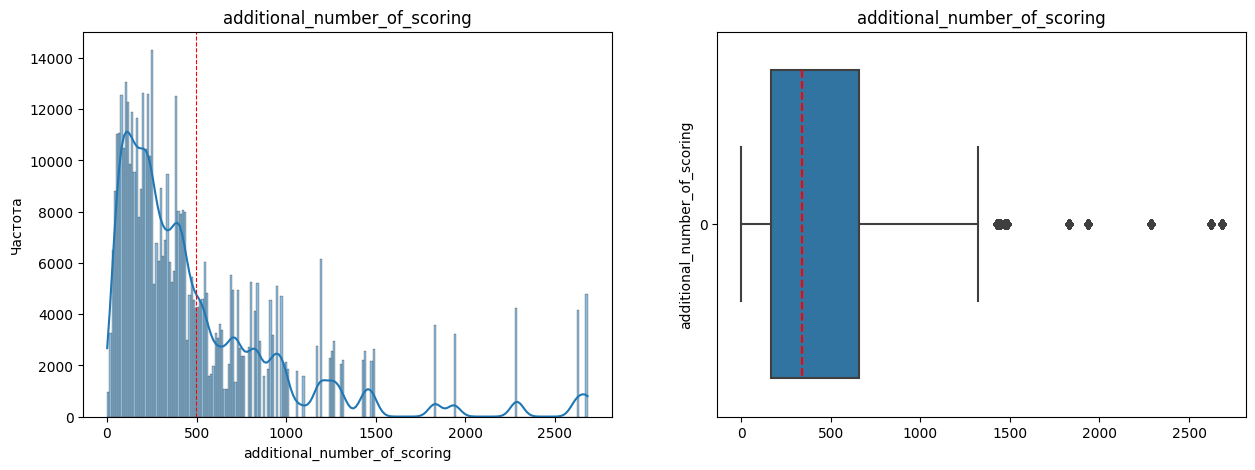

In [102]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['additional_number_of_scoring'], kde=True, ax=axes[0])

axes[0].set(xlabel='additional_number_of_scoring', ylabel='Частота')
axes[0].set_title('additional_number_of_scoring')
axes[0].axvline(data['additional_number_of_scoring'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['additional_number_of_scoring'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='additional_number_of_scoring')
axes[1].set_title('additional_number_of_scoring')

plt.show()

### 'total_number_of_reviews'

Text(0.5, 1.0, 'total_number_of_reviews')

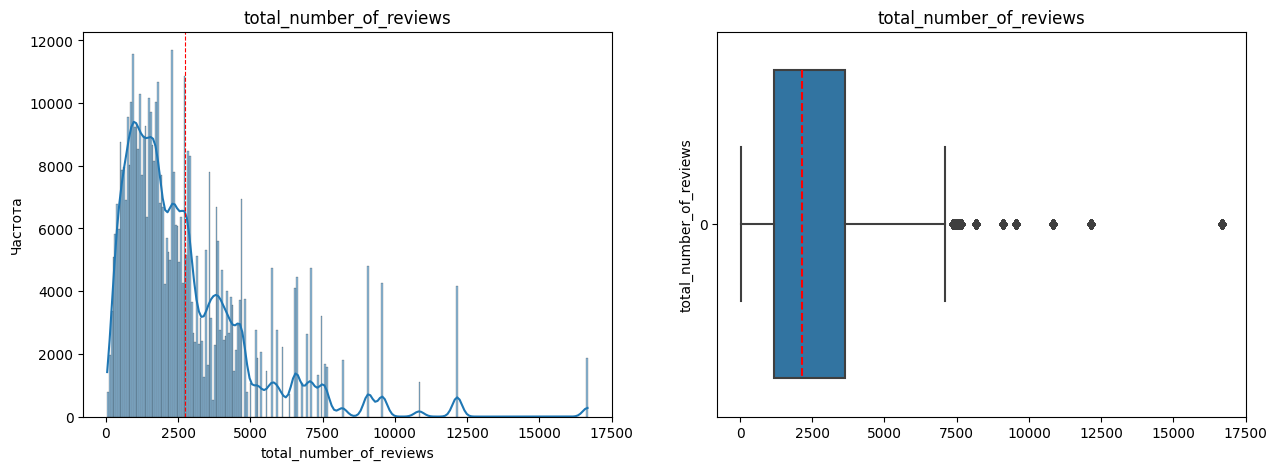

In [103]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['total_number_of_reviews'], kde=True, ax=axes[0])

axes[0].set(xlabel='total_number_of_reviews', ylabel='Частота')
axes[0].set_title('total_number_of_reviews')
axes[0].axvline(data['total_number_of_reviews'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['total_number_of_reviews'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='total_number_of_reviews')
axes[1].set_title('total_number_of_reviews')

In [104]:
#удалим признак
data = data.drop(['additional_number_of_scoring'], axis=1)

Эти два признака имеют высокую корреляцию, поэтому оставим один из них. Для меня логически более понятен признак total_number_of_reviews — общее количество действительных отзывов об отеле.
его и оставим, признак additional_number_of_scoring будет удален. Более того, total_number_of_reviews визуально имеет меньше выбросов, поработаем над ними.

Тк данный признак не распределен нормально, то можно преобразовать его через логарифм и далее использовать логарифм от данного признака

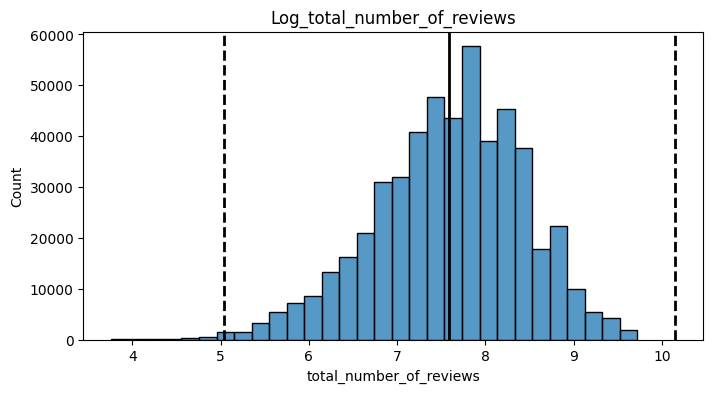

In [105]:
#визуализируем 
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_num_reviews = np.log(data['total_number_of_reviews'])
histplot = sns.histplot(log_num_reviews, bins=30, ax=ax)
histplot.axvline(log_num_reviews.mean(), color='k', lw=2)
histplot.axvline(log_num_reviews.mean()+ 3 * log_num_reviews.std(), color='k', ls='--', lw=2)
histplot.axvline(log_num_reviews.mean()- 3 * log_num_reviews.std(), color='k', ls='--', lw=2)
histplot.set_title('Log_total_number_of_reviews');

После преобразования видим, что распределение не симметрично, левый хвост боьше правого.
Для поиска выбросов применим метод z-отклонений, модифицировав его на ручной ввод кол-ва сигм

In [106]:
#метода z-отклонения
def outliers_z_score_mod(data, feature, log_scale=False, left = 3, right = 3):
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    
    return outliers, cleaned

In [107]:
#тк распределение не симметрично, то мы дали левому хвосту послабление на 4 сигмы (если взять 5 сигм, то выбросов не будет)
outliers, cleaned = outliers_z_score_mod(data, 'total_number_of_reviews', log_scale=True, left = 4, right = 3)
print(f'Число выбросов по методу z-отклонения: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')
print("Кол-во уникальный выбросов:", outliers['total_number_of_reviews'].nunique())

Число выбросов по методу z-отклонения: 236
Результирующее число записей: 515195
Кол-во уникальный выбросов: 9


In [108]:
# заменим выбросы на минимальное значение очищенных данных

outliers_list = list(outliers['total_number_of_reviews'].unique())
min_value = cleaned[['total_number_of_reviews']].min()
print(outliers_list, min_value)

def change_outliers (data):
    if data in outliers_list:
        return min_value['total_number_of_reviews']
    else:
        return data

data['total_number_of_reviews_upd'] = data ['total_number_of_reviews'].apply(change_outliers)

[59, 64, 60, 49, 51, 43, 61, 54, 45] total_number_of_reviews    66
dtype: int64


In [109]:
#создадим новый признак - логарифм от признака  total_number_of_reviews_upd
data['Log_total_number_of_reviews'] = np.log(data['total_number_of_reviews_upd'])
data['Log_total_number_of_reviews'] 

0         9.721366
1         8.520787
2         5.860786
3         7.341484
4         8.452548
            ...   
515426    6.424869
515427    8.078378
515428    7.919720
515429    7.356918
515430    7.097549
Name: Log_total_number_of_reviews, Length: 515431, dtype: float64

In [110]:
data['Log_total_number_of_reviews'].describe()

count    515431.000000
mean          7.590542
std           0.852041
min           4.189655
25%           7.057037
50%           7.665753
75%           8.197814
max           9.721366
Name: Log_total_number_of_reviews, dtype: float64

In [111]:
#удалим признак
data = data.drop(['total_number_of_reviews_upd'], axis=1)
data = data.drop(['total_number_of_reviews'], axis=1)

### 'review_date'

In [112]:
#переведем в нужный формат данные, посчитаем показатель, и сохраним новый признак
data['review_date'] = pd.to_datetime(data['review_date'], dayfirst=False)
max_date = data['review_date'].max()
data['actuality_review'] = max_date-data['review_date']
data['actuality_review'] = pd.to_numeric(data['actuality_review'].dt.days, downcast='integer')

Text(0.5, 1.0, 'actuality_review')

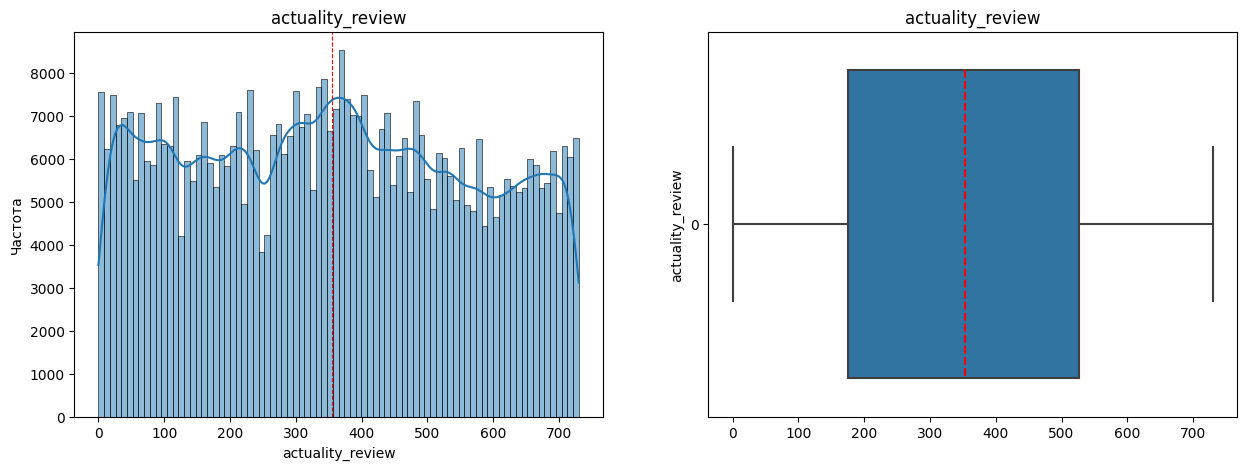

In [113]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['actuality_review'], kde=True, ax=axes[0])

axes[0].set(xlabel='actuality_review', ylabel='Частота')
axes[0].set_title('actuality_review')
axes[0].axvline(data['actuality_review'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['actuality_review'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='actuality_review')
axes[1].set_title('actuality_review')

In [114]:
#появилась идея, добавить признак месяца года, а также отделить "1 квартал", 
data['month_of_review'] = pd.DatetimeIndex(data['review_date']).month
data['quat_1'] = data['month_of_review'].apply(lambda x: 1 if x == 1 or x== 2 or x== 3  else 0 )
data['quat_1'] 

0         0
1         0
2         0
3         0
4         0
         ..
515426    0
515427    1
515428    1
515429    0
515430    0
Name: quat_1, Length: 515431, dtype: int64

In [115]:
data['month_of_review'].describe()

count    515431.00000
mean          6.48623
std           3.35188
min           1.00000
25%           4.00000
50%           7.00000
75%           9.00000
max          12.00000
Name: month_of_review, dtype: float64

In [116]:
data['month_of_review'].corr(data['quat_1'])

-0.7450349749725691

<Axes: xlabel='quat_1', ylabel='reviewer_score'>

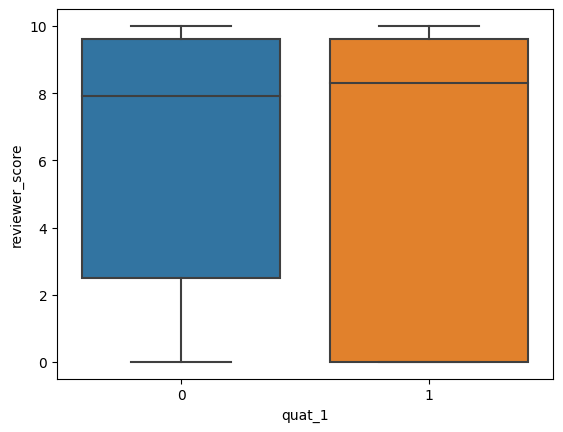

In [117]:
a = sns.boxplot(data=data, x="quat_1", y="reviewer_score")
a

### 'average_score'

Text(0.5, 1.0, 'average_score')

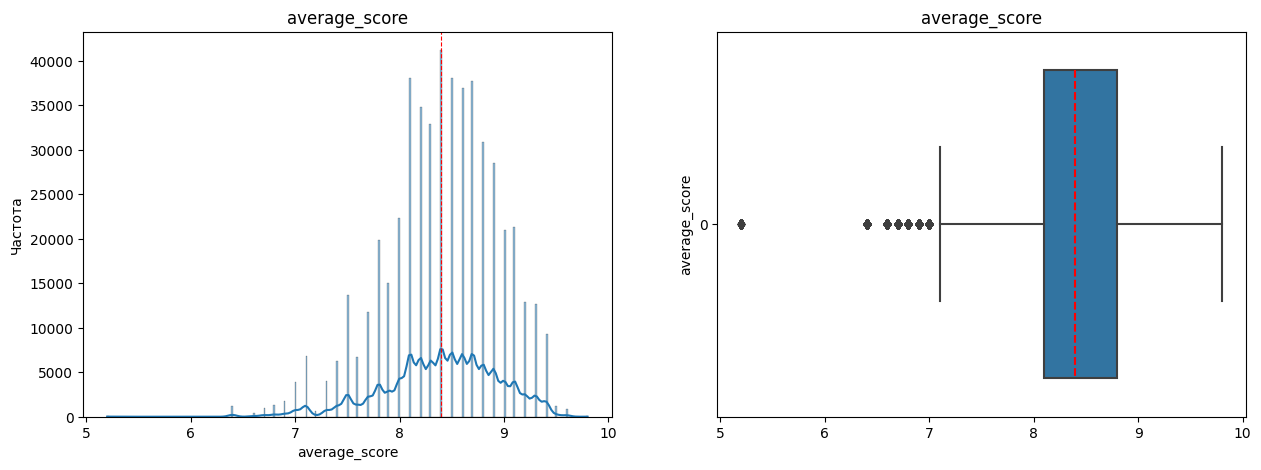

In [118]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['average_score'], kde=True, ax=axes[0])

axes[0].set(xlabel='average_score', ylabel='Частота')
axes[0].set_title('average_score')
axes[0].axvline(data['average_score'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['average_score'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='average_score')
axes[1].set_title('average_score')

Предлагаю заменить отдельно-стоящие наблюдения (65 шт) - 5.2 на близлежащие к ним - 6.4. Т.к. можно предположить данные наблюдения являются выбросами

In [119]:
data['average_score'] = data['average_score'].apply(lambda x: 6.4 if x == 5.2 else x )

<Axes: xlabel='average_score', ylabel='reviewer_score'>

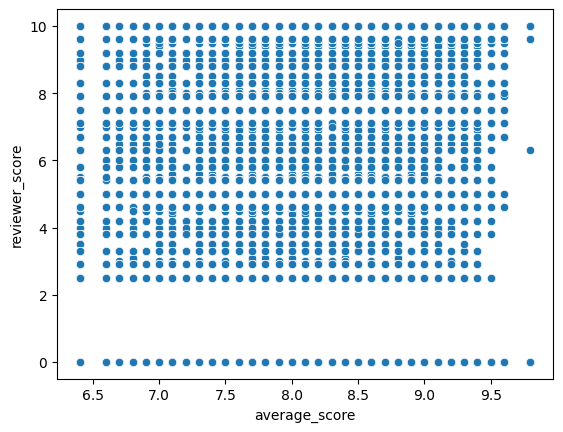

In [120]:
a = sns.scatterplot(data=data, x="average_score", y="reviewer_score")
a

возьмем в моделирование

### 'hotel_name' 

In [121]:
#создадим новый признак
data['hotel_name_count'] = data['hotel_name'].str.split().apply(len)
data['hotel_name_count']

0         3
1         3
2         6
3         4
4         3
         ..
515426    2
515427    5
515428    3
515429    4
515430    3
Name: hotel_name_count, Length: 515431, dtype: int64

In [122]:
data['hotel_name'] =  data['hotel_name'].str.lower()

In [123]:
#создадим новый признак, что отель входит в топ сетевых отелей европы (список взяла с первой ссылки в интернете)

def find_top_hotels (data):
    top_hotels_list = ['hilton', 'marriott','hyatt','sheraton','wyndham', 'accor','carlson', 'choice', 'holiday', 'western']
    words = data.split()
    count = 0
    for word in words:
        if word in top_hotels_list:
            return 1
        else: return 0

data['top_hotels_flag'] = data['hotel_name'].apply(find_top_hotels)

In [124]:
data['top_hotels_flag'].groupby(data['top_hotels_flag']).count()

top_hotels_flag
0    481757
1     33674
Name: top_hotels_flag, dtype: int64

<Axes: xlabel='top_hotels_flag', ylabel='reviewer_score'>

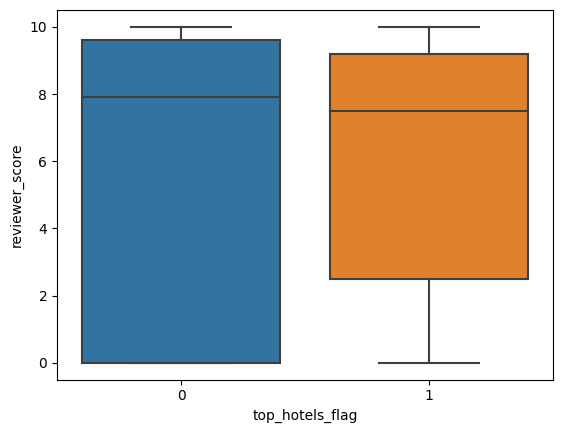

In [125]:
a = sns.boxplot(data=data, x="top_hotels_flag", y="reviewer_score")
a

<Axes: xlabel='hotel_name_count', ylabel='reviewer_score'>

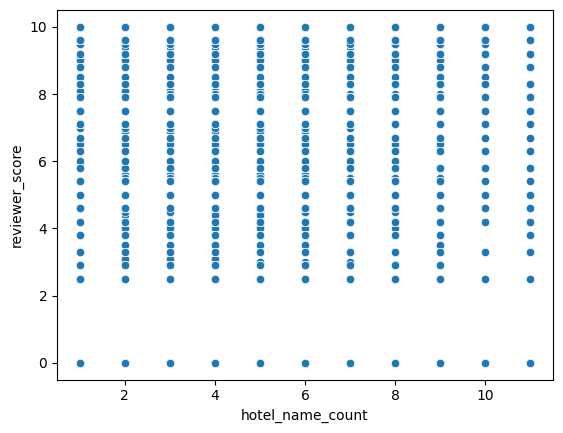

In [126]:
a = sns.scatterplot(data=data, x="hotel_name_count", y="reviewer_score")
a

### 'reviewer_nationality' к удалению

In [130]:
data['reviewer_nationality']

0                   United Kingdom
1                          Belgium
2                           Sweden
3         United States of America
4                   United Kingdom
                    ...           
515426                      France
515427                      Turkey
515428                 Netherlands
515429        United Arab Emirates
515430                   Australia
Name: reviewer_nationality, Length: 515431, dtype: object

In [131]:
data['reviewer_nationality'] = data['reviewer_nationality'].apply(lambda x: x.strip())
data['reviewer_nationality']

0                   United Kingdom
1                          Belgium
2                           Sweden
3         United States of America
4                   United Kingdom
                    ...           
515426                      France
515427                      Turkey
515428                 Netherlands
515429        United Arab Emirates
515430                   Australia
Name: reviewer_nationality, Length: 515431, dtype: object

In [151]:
top_nationalities = data['reviewer_nationality'].groupby(data['reviewer_nationality']).count().sort_values(ascending=False).head(10)
top_nationalities


reviewer_nationality
United Kingdom              245165
United States of America     35390
Australia                    21663
Ireland                      14820
United Arab Emirates         10230
Saudi Arabia                  8945
Netherlands                   8762
Switzerland                   8672
Germany                       7936
Canada                        7887
Name: reviewer_nationality, dtype: int64

In [152]:
data['top_reviewer_nationality'] = data['reviewer_nationality'].apply(lambda x: x if x in top_nationalities else 'Other' )

<Axes: xlabel='top_reviewer_nationality', ylabel='reviewer_score'>

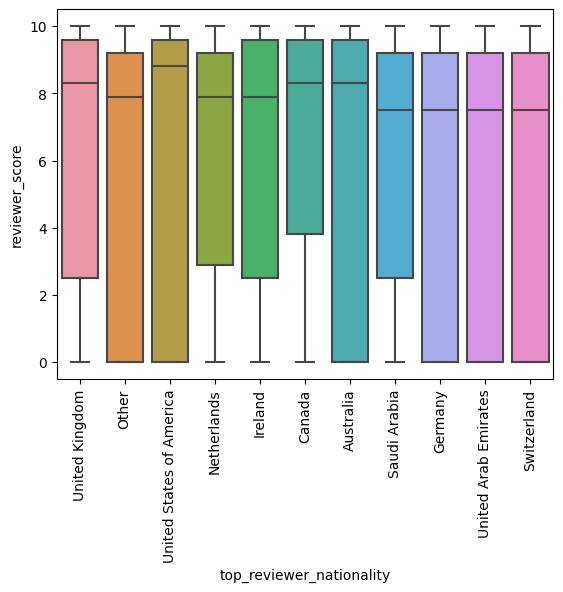

In [153]:
a = sns.boxplot(data=data, x="top_reviewer_nationality", y="reviewer_score")
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a

In [154]:
#data['country_hotel_nationality'] = data['country_hotel'].equals(data['reviewer_nationality'])

#data['country_hotel_nationality'] = np.where(data['country_hotel'] == data['country_hotel'])


#data['country_hotel_nationality'] = data.apply(lambda x: 1 if data['country_hotel'] == data['country_hotel'] else 0)


data['country_hotel_nationality'] = data['country_hotel'] == data['reviewer_nationality']
data['country_hotel_nationality'] = data['country_hotel_nationality'].apply(lambda x: 1 if x ==True else 0)

data['country_hotel_nationality'].groupby(data['country_hotel_nationality']).count().head(10)

country_hotel_nationality
0    337047
1    178384
Name: country_hotel_nationality, dtype: int64

<Axes: xlabel='country_hotel_nationality', ylabel='reviewer_score'>

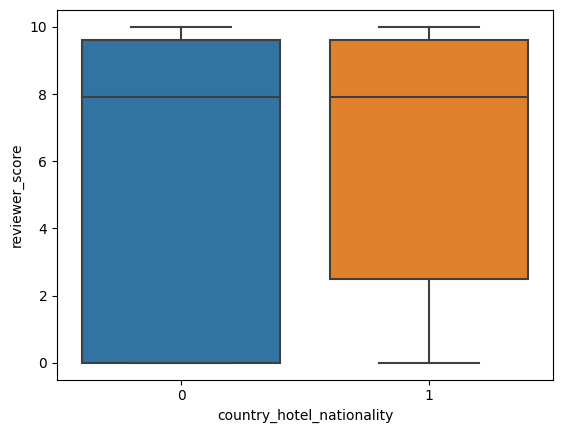

In [155]:
a = sns.boxplot(data=data, x="country_hotel_nationality", y="reviewer_score")
a

In [559]:
data['country_hotel'].groupby(data['country_hotel']).count().head(10)

country_hotel
Austria            38938
France             59626
Italy              37206
Netherlands        57212
Spain              60149
United Kingdom    262300
Name: country_hotel, dtype: int64

### negative_review 
### review_total_negative_word_counts
### positive_review
### review_total_positive_word_counts


In [156]:
# в колонках review_total_negative_word_counts и review_total_positive_word_counts выявлены несоотвествия фактическому кол-ву слов в отзыве с указанными значениями кол-ва слов,
#поэтому необходимо скорректировать данные - посчитаем кол-во слов и после удалим другие признаки

data['neg_review_count'] = data['negative_review'].str.split().apply(len)
data['pos_review_count'] = data['positive_review'].str.split().apply(len)

In [157]:
# также на основании данного признака можно создать новый признак: соотношение длины положит и отрицательного отзыва, логика в нем: что чем ниже/выше оценка - тем больше будет слов в отрицательном
# положительном отзыве

data['pos_neg_ratio'] = data['pos_review_count']/(data['neg_review_count']+1)


In [158]:
data['pos_neg_ratio'].describe()

count    515431.000000
mean          2.813970
std           5.423249
min           0.000000
25%           0.333333
50%           1.000000
75%           3.000000
max         225.000000
Name: pos_neg_ratio, dtype: float64

<Axes: xlabel='pos_neg_ratio', ylabel='reviewer_score'>

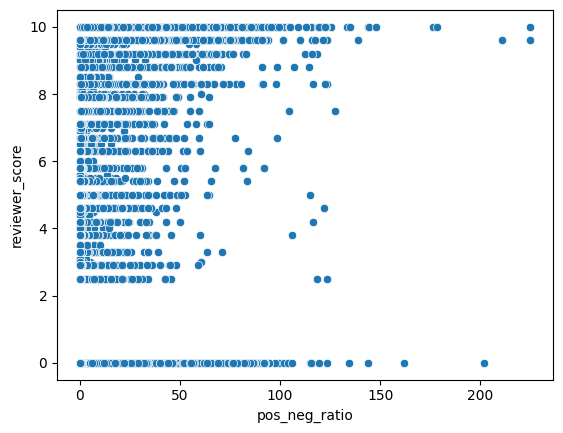

In [159]:
a = sns.scatterplot(data=data, x="pos_neg_ratio", y="reviewer_score")
a

In [160]:
data['positive_review'] = data['positive_review'].str.lower()
data['negative_review'] = data['negative_review'].str.lower()

In [161]:
def find_pos_word (data):

    positive_words_list = ['great','good','perfect', 'excellent','perfect','nice','lovely','comfortable', 'very', 'clean', 'friendly','pleasant', 'helpful']
    words = data.split()
    count = 0
    for word in words:
        if word in positive_words_list:
            count +=1
    return count

data['positive_words_count'] = data['positive_review'].apply(find_pos_word)

<Axes: xlabel='positive_words_count', ylabel='reviewer_score'>

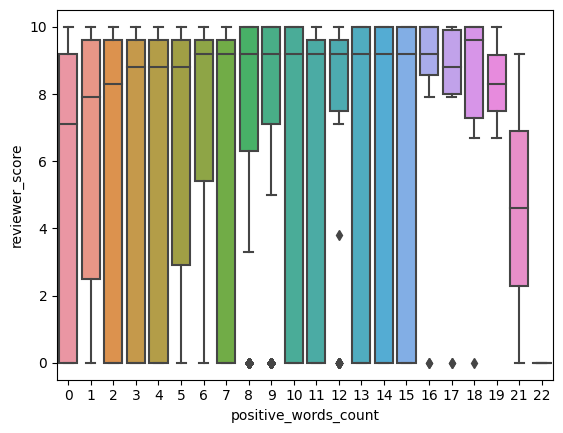

In [162]:
a = sns.boxplot(data=data, x = 'positive_words_count', y = 'reviewer_score' )
a

In [163]:
def find_no_neg_words (data):

    no_neg_words_list = ['no complaints','no negative','nothing', 'n a','none',' ','all good','nothing really', 'no complaints', 'nil', 'mothing at all','nothing to dislike',
                         'can t think of anything','absolutely nothing', 'no', 'everything was perfect', 'everything was great', 'nothing to complain about', 'liked everything'
                         ]
    data = data.strip()
    if data in no_neg_words_list:
        return 1
    else: return 0

data['no_negative_words_flag'] = data['negative_review'].apply(find_no_neg_words)

In [164]:
data['no_negative_words_flag'].groupby(data['no_negative_words_flag']).count()

no_negative_words_flag
0    359151
1    156280
Name: no_negative_words_flag, dtype: int64

<Axes: xlabel='no_negative_words_flag', ylabel='reviewer_score'>

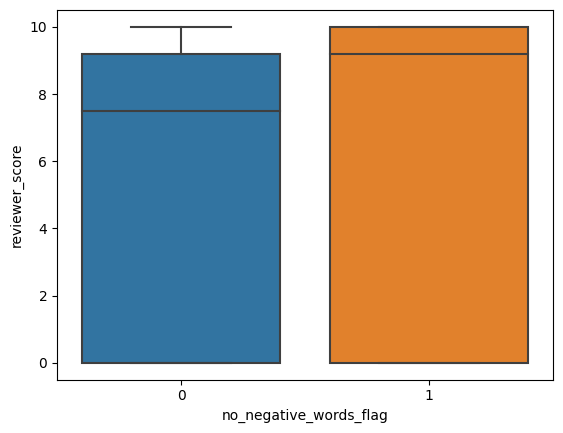

In [165]:
a = sns.boxplot(data=data, x = 'no_negative_words_flag', y = 'reviewer_score' )
a

In [166]:
data = data.drop(['reviewer_nationality'], axis=1)
data = data.drop(['negative_review'], axis=1)
data = data.drop(['positive_review'], axis=1)
data = data.drop(['review_total_negative_word_counts'], axis=1)
data = data.drop(['review_total_positive_word_counts'], axis=1)

### 'total_number_of_reviews_reviewer_has_given'

Text(0.5, 1.0, 'total_number_of_reviews_reviewer_has_given')

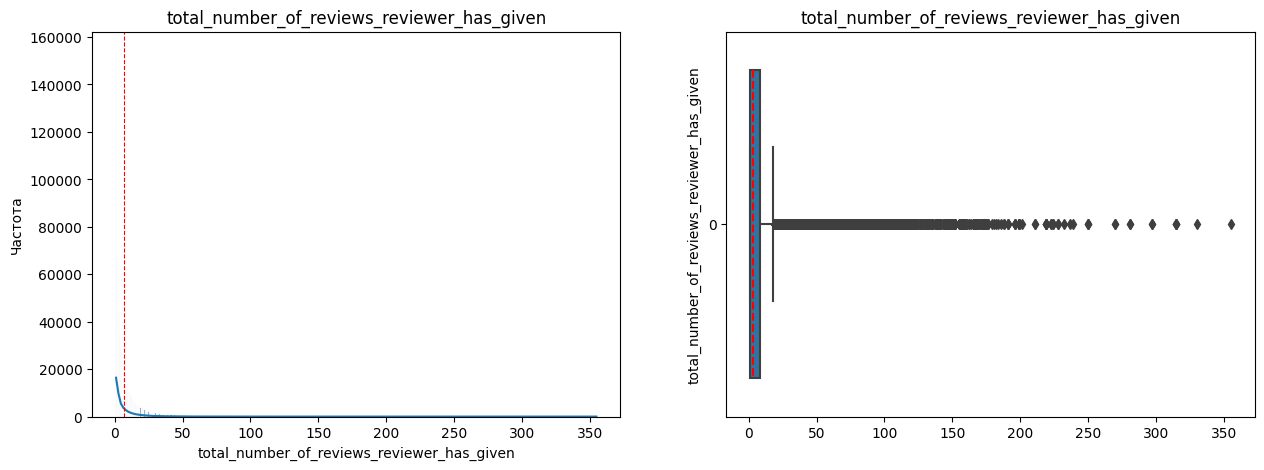

In [167]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['total_number_of_reviews_reviewer_has_given'], kde=True, ax=axes[0])

axes[0].set(xlabel='total_number_of_reviews_reviewer_has_given', ylabel='Частота')
axes[0].set_title('total_number_of_reviews_reviewer_has_given')
axes[0].axvline(data['total_number_of_reviews_reviewer_has_given'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['total_number_of_reviews_reviewer_has_given'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='total_number_of_reviews_reviewer_has_given')
axes[1].set_title('total_number_of_reviews_reviewer_has_given')

In [168]:
data['total_number_of_reviews_reviewer_has_given'].describe()

count    515431.000000
mean          7.165215
std          11.038742
min           1.000000
25%           1.000000
50%           3.000000
75%           8.000000
max         355.000000
Name: total_number_of_reviews_reviewer_has_given, dtype: float64

In [176]:
# для нормализации, стандартизации
from sklearn import preprocessing

In [180]:
# инициализируем нормализатор RobustScaler
r_scaler = preprocessing.RobustScaler()

# кодируем исходный датасет
data['norm_total_num_reviews_has_given']  = r_scaler.fit_transform(data[['total_number_of_reviews_reviewer_has_given']])
data['norm_total_num_reviews_has_given'].describe()



count    515431.000000
mean          0.595031
std           1.576963
min          -0.285714
25%          -0.285714
50%           0.000000
75%           0.714286
max          50.285714
Name: norm_total_num_reviews_has_given, dtype: float64

Text(0.5, 1.0, 'norm_total_num_reviews_has_given')

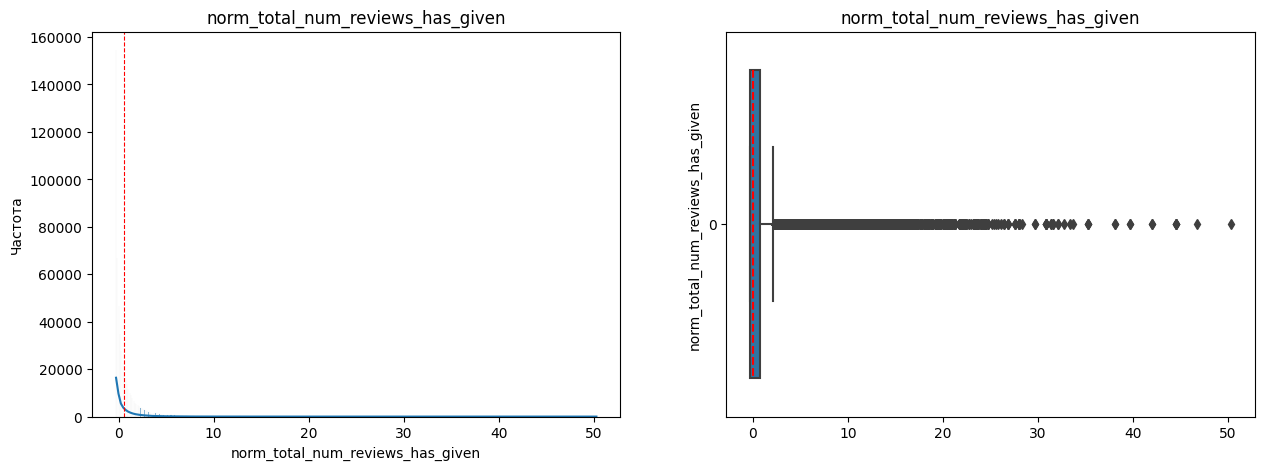

In [181]:
#визуализируем распределение признака

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['norm_total_num_reviews_has_given'], kde=True, ax=axes[0])

axes[0].set(xlabel='norm_total_num_reviews_has_given', ylabel='Частота')
axes[0].set_title('norm_total_num_reviews_has_given')
axes[0].axvline(data['norm_total_num_reviews_has_given'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['norm_total_num_reviews_has_given'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(ylabel='norm_total_num_reviews_has_given')
axes[1].set_title('norm_total_num_reviews_has_given')

возьмем признак в моделирование

### 'tags' 

In [182]:
#обработаем теги
new_tags = data['tags'].str.replace(" ']", '')
new_tags = new_tags.str.replace("[' ", '')
new_tags = new_tags.str.replace("' ", '')
new_tags = new_tags.str.replace(" '", '')


tags_a= pd.DataFrame()
tags_a['tags'] = new_tags.astype(str)

#с животными
tags_a['pet'] = tags_a['tags'].apply(lambda x: 1 if x.split(', ')[0] == 'With a pet' else 0 )
tags_a['cleaned_tags'] = tags_a['tags'].str.replace('With a pet, ', '')

#с мобильного
tags_a['device'] = tags_a['tags'].apply(lambda x: 1 if x.split(', ')[-1] == 'Submitted from a mobile device' else 0 )
tags_a['cleaned_tags'] = tags_a['cleaned_tags'].str.replace(', Submitted from a mobile device', '')

#команировка/отдых
tags_a['trip_type'] = tags_a['cleaned_tags'].apply(lambda x: x.split(', ')[0] if x.split(', ')[0] == 'Leisure trip' or x.split(', ')[0] == 'Business trip' else 'NA'  )
tags_a['cleaned_tags'] = tags_a['cleaned_tags'].str.replace('Leisure trip, ', '')
tags_a['cleaned_tags'] = tags_a['cleaned_tags'].str.replace('Business trip, ', '')

#компания
tags_a['traveler'] = tags_a['cleaned_tags'].apply(lambda x: x.split(', ')[0])
list_of_rep = ['Couple,', 'Solo traveler', 'Family with young children', 'Group',
       'Family with older children', 'Travelers with friends']

tags_a['cleaned_tags'] = tags_a['cleaned_tags'].str.replace('Couple, ', '').str.replace('Solo traveler, ', '').str.replace('Family with young children, ', '').str.replace('Solo traveler, ', '')
tags_a['cleaned_tags'] = tags_a['cleaned_tags'].str.replace('Group', '').str.replace('Group, ', '').str.replace('Family with older children, ', '').str.replace('Travelers with friends, ', '')


#срок пребывания (в строке попались некоторые ошибки, которые надо вычистить)
tags_a['duration_of_stay'] = tags_a['cleaned_tags'].apply(lambda x: x.split(', ')[-1])
#чтобы вычистить ошибки, очистим информацию и оставим только числовое значение кол-ва ночей ипользуя регулярное значение
tags_a['number_of_days'] = tags_a['duration_of_stay'].str.extract('(\d+)', expand=False)
tags_a['number_of_days'] = tags_a['number_of_days'].astype(float)
#удалим столбец с ошибками
tags_a = tags_a.drop(['duration_of_stay'], axis=1)
#удалим вспомогательный столбец cleaned_tags
tags_a = tags_a.drop(['cleaned_tags'], axis=1)
#добавим информацию о кол-ве тегов
tags_a['tags_num'] = data['tags'].str.count(',')+1

#объедим датасеты
data = pd.merge(
    data,
    tags_a,
    how="left",
    left_index=True, 
    right_index=True
)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 34 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   hotel_address                               515431 non-null  object        
 1   review_date                                 515431 non-null  datetime64[ns]
 2   average_score                               515431 non-null  float64       
 3   hotel_name                                  515431 non-null  object        
 4   total_number_of_reviews_reviewer_has_given  515431 non-null  int64         
 5   tags_x                                      515431 non-null  object        
 6   days_since_review                           515431 non-null  object        
 7   lat                                         512163 non-null  float64       
 8   lng                                         512163 non-null  float64      

<Axes: xlabel='trip_type', ylabel='reviewer_score'>

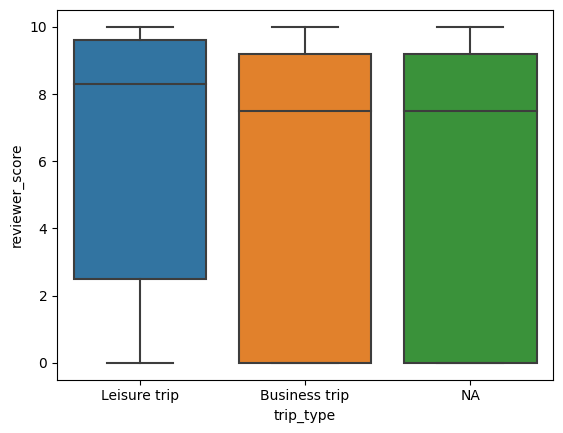

In [183]:
a = sns.boxplot(data=data, x="trip_type", y="reviewer_score")
a

In [184]:
data['leisure_trip'] = data['trip_type'].apply(lambda x: 1 if x == 'Leisure trip' else 0 )

<Axes: xlabel='leisure_trip', ylabel='reviewer_score'>

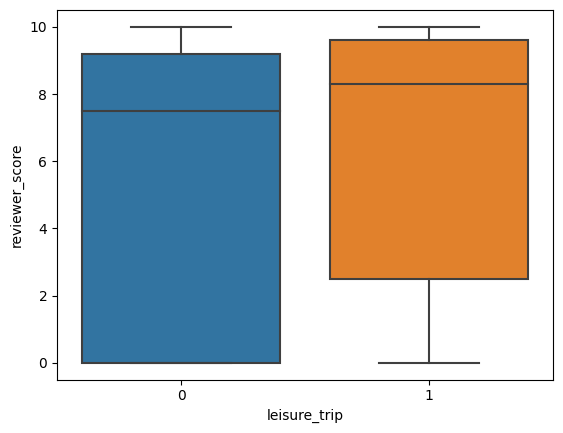

In [185]:
a = sns.boxplot(data=data, x="leisure_trip", y="reviewer_score")
a

### 'days_since_review'

In [186]:
#оставим только цифру 
data['days_since_review_num'] =  data['days_since_review'].str.extract('(\d+)', expand=False).astype(float)


### 'lat'

In [187]:
#в данном поле есть пропуски, их необходимо обработать
print('всего таких отеля с пропусками:', data[data['lat'].isnull()]['hotel_address'].nunique())

#всего таких отеля с пропусками 17 штук, поэтому можно внести инфомрацию достаточно точно

lat = data[data['lat'].isnull()]['hotel_address'].unique() 
lng = data[data['lng'].isnull()]['hotel_address'].unique()
print('пропуски долготы и ширины совпадают:',lat == lng)

всего таких отеля с пропусками: 17
пропуски долготы и ширины совпадают: [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]


In [194]:
# как вариант найти долготу и широту для данных адресов, я использовала сайт https://coordinates-converter.com/en/ (искала до индекса b bkb yfpdfybt hfqjyf,тк в названиях улиц много ошибок)

find_lat_lng= data[data['lat'].isnull()].groupby('hotel_address').count()[['lat', 'lng']]
find_lat_lng

,lat,lng
hotel_address,,


In [189]:

lat_lng = [[48.85889, 2.320041],
           [48.853495, 2.348391],
           [48.85889, 2.320041],
           [41.382894, 2.177432],
           
           [48.225073, 16.358398],
           [48.208354, 16.372504],
           [48.210852, 16.34736],
           [48.210852, 16.34736],
           [48.208354, 16.372504],
           [48.163109,16.458013],
           
           [41.393689,2.163655],
           
           [48.214955,16.302153],
           
           [41.393689,2.163655],
           
           [48.208354,16.372504],
           [48.200638,16.426895],
           [48.225073,16.426895],
           [48.225073,16.426895]]

In [195]:
for i in range (17):
    find_lat_lng.iloc[i] = lat_lng[i]
find_lat_lng

IndexError: iloc cannot enlarge its target object

In [196]:
data = data.set_index('hotel_address')
data.update(find_lat_lng)
data = data.reset_index()

In [197]:
data['lat']

0         45.533137
1         52.385649
2         41.393192
3         45.479888
4         52.370545
            ...    
515426    51.494028
515427    48.192379
515428    51.520795
515429    51.515125
515430    51.493109
Name: lat, Length: 515431, dtype: float64

In [198]:
data['lng']

0          9.171102
1          4.834443
2          2.161520
3          9.196298
4          4.888644
            ...    
515426    -0.191050
515427    16.399451
515428    -0.131084
515429    -0.160066
515430    -0.190208
Name: lng, Length: 515431, dtype: float64

In [199]:
# инициализируем нормализатор RobustScaler
r_scaler = preprocessing.RobustScaler()

# кодируем исходный датасет
data['lng_norm']  = r_scaler.fit_transform(data[['lng']])
data['lat_norm']  = r_scaler.fit_transform(data[['lat']])


In [200]:
data.columns

Index(['hotel_address', 'review_date', 'average_score', 'hotel_name',
       'total_number_of_reviews_reviewer_has_given', 'tags_x',
       'days_since_review', 'lat', 'lng', 'sample', 'reviewer_score',
       'country_hotel', 'city_hotel', 'Log_total_number_of_reviews',
       'actuality_review', 'month_of_review', 'quat_1', 'hotel_name_count',
       'top_hotels_flag', 'top_reviewer_nationality',
       'country_hotel_nationality', 'neg_review_count', 'pos_review_count',
       'pos_neg_ratio', 'positive_words_count', 'no_negative_words_flag',
       'norm_total_num_reviews_has_given', 'tags_y', 'pet', 'device',
       'trip_type', 'traveler', 'number_of_days', 'tags_num', 'leisure_trip',
       'days_since_review_num', 'lng_norm', 'lat_norm'],
      dtype='object')

In [201]:
#удалим признаки, которые были к удалению по итогам анализа и промежуточные столбцы
data = data.drop([ 'hotel_name','hotel_address','review_date', 'days_since_review','tags_y','tags_x'], axis=1)


<Axes: >

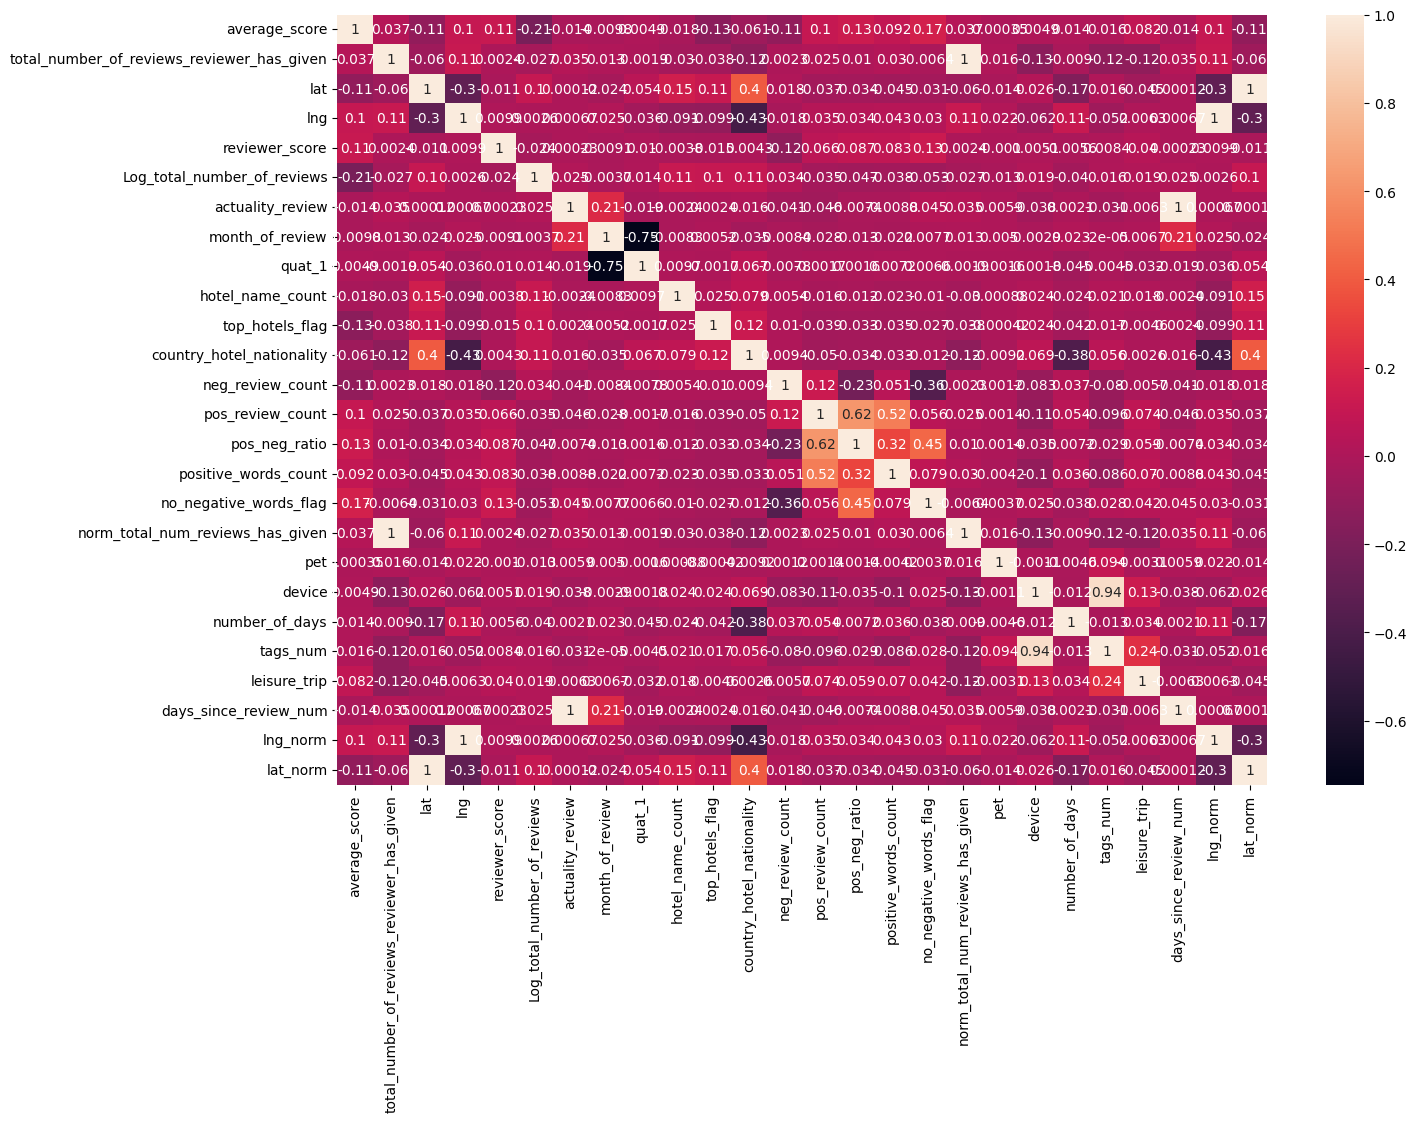

In [202]:
#теперь посмотрим что получилось в корреляционной матрице
plt.rcParams['figure.figsize'] = (15,10)
sns.heatmap(data.drop(['sample'], axis=1).corr(numeric_only=True), annot=True)

In [204]:
data.columns

Index(['average_score', 'total_number_of_reviews_reviewer_has_given', 'lat',
       'lng', 'sample', 'reviewer_score', 'country_hotel', 'city_hotel',
       'Log_total_number_of_reviews', 'actuality_review', 'month_of_review',
       'quat_1', 'hotel_name_count', 'top_hotels_flag',
       'top_reviewer_nationality', 'country_hotel_nationality',
       'neg_review_count', 'pos_review_count', 'pos_neg_ratio',
       'positive_words_count', 'no_negative_words_flag',
       'norm_total_num_reviews_has_given', 'pet', 'device', 'trip_type',
       'traveler', 'number_of_days', 'tags_num', 'leisure_trip',
       'days_since_review_num', 'lng_norm', 'lat_norm'],
      dtype='object')

In [205]:
#видим, что сохраняются пары признаков с высокой корреляцией, удалим один из каждой пары
data = data.drop(['actuality_review','device','lat','lng', 'total_number_of_reviews_reviewer_has_given'], axis=1)

<Axes: >

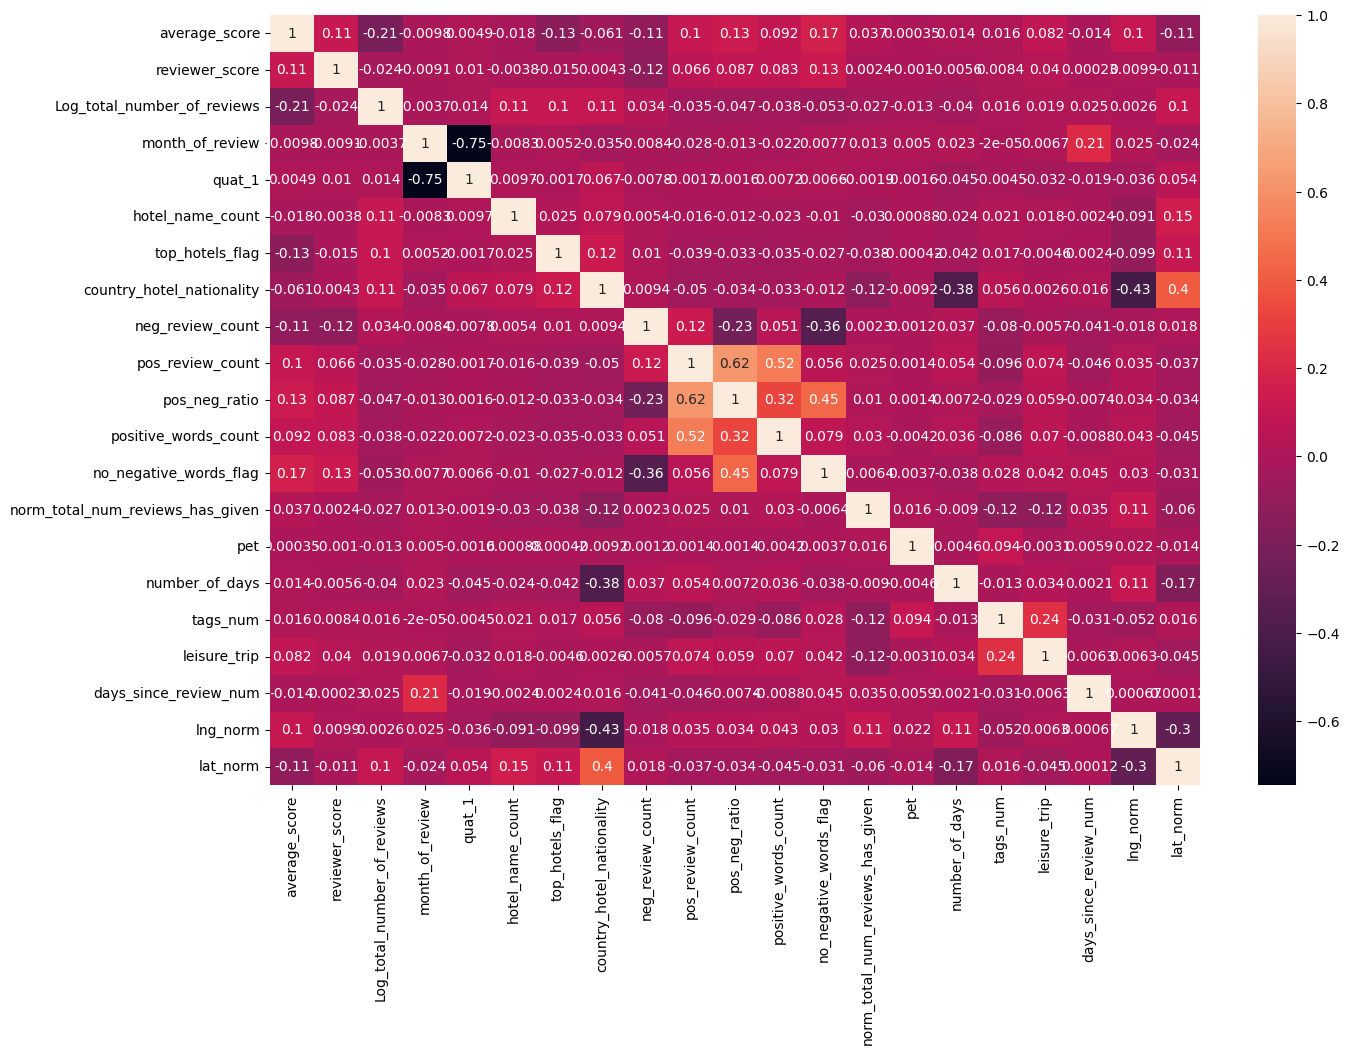

In [206]:
#теперь посмотрим что получилось в корреляционной матрице
plt.rcParams['figure.figsize'] = (15,10)
sns.heatmap(data.drop(['sample'], axis=1).corr(numeric_only=True), annot=True)

In [207]:
#видим, что сохраняются пары признаков с высокой корреляцией, удалим один из каждой пары
data = data.drop(['quat_1'], axis=1)

# Очистка данных повторная, после добавления признаков

In [208]:
#проверка на наличие пропусков
cols_null_percent = data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

number_of_days    0.03725
dtype: float64

In [209]:
#заменим отсутствующие означения на моду

#создаём словарь 'имя_столбца': число (признак), на который надо заменить пропуски 
values = {
    'number_of_days': data['number_of_days'].mode()[0]
    
}
#заполняем оставшиеся записи константами в соответствии со словарем values
data = data.fillna(values)
#выводим результирующую долю пропусков
display(data.isnull().mean())

average_score                       0.0
sample                              0.0
reviewer_score                      0.0
country_hotel                       0.0
city_hotel                          0.0
Log_total_number_of_reviews         0.0
month_of_review                     0.0
hotel_name_count                    0.0
top_hotels_flag                     0.0
top_reviewer_nationality            0.0
country_hotel_nationality           0.0
neg_review_count                    0.0
pos_review_count                    0.0
pos_neg_ratio                       0.0
positive_words_count                0.0
no_negative_words_flag              0.0
norm_total_num_reviews_has_given    0.0
pet                                 0.0
trip_type                           0.0
traveler                            0.0
number_of_days                      0.0
tags_num                            0.0
leisure_trip                        0.0
days_since_review_num               0.0
lng_norm                            0.0


In [210]:
#проверка на наличие неинформативных признаков

#список неинформативных признаков
low_information_cols = [] 

#цикл по всем столбцам
for col in data.columns:
    #наибольшая относительная частота в признаке
    top_freq = data[col].value_counts(normalize=True).max()
    #доля уникальных значений от размера признака
    nunique_ratio = data[col].nunique() / data[col].count()
    # сравниваем наибольшую частоту с порогом
    if top_freq > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% одинаковых значений')
    # сравниваем долю уникальных значений с порогом
    if nunique_ratio > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% уникальных значений')
        
low_information_cols        

pet: 99.73% одинаковых значений


['pet']

In [211]:
#удалим неинформативный признак
data = data.drop(['pet'], axis=1)

## Преобразование категориальных признаков

In [212]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 25 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   average_score                     515431 non-null  float64
 1   sample                            515431 non-null  int64  
 2   reviewer_score                    515431 non-null  float64
 3   country_hotel                     515431 non-null  object 
 4   city_hotel                        515431 non-null  object 
 5   Log_total_number_of_reviews       515431 non-null  float64
 6   month_of_review                   515431 non-null  int32  
 7   hotel_name_count                  515431 non-null  int64  
 8   top_hotels_flag                   515431 non-null  int64  
 9   top_reviewer_nationality          515431 non-null  object 
 10  country_hotel_nationality         515431 non-null  int64  
 11  neg_review_count                  515431 non-null  i

In [214]:
#нам необходимо преобразовать следующие признаки (типа Object) - country_hotel, device, trip_type, traveler
data[['country_hotel', 'trip_type', 'traveler','city_hotel','top_reviewer_nationality']].nunique()

country_hotel                6
trip_type                    3
traveler                     6
city_hotel                   6
top_reviewer_nationality    11
dtype: int64

In [215]:

data = data.drop(['trip_type'], axis=1)

в нашем случае достаточно применить ОДНОКРАТНОЕ КОДИРОВАНИЕ. ONE-HOT ENCODING

In [216]:
import category_encoders as ce # импорт для работы с кодировщиком

encoder = ce.OneHotEncoder(cols=['country_hotel', 'traveler','city_hotel','top_reviewer_nationality']) # указываем столбец для кодирования
type_bin = encoder.fit_transform(data[['country_hotel', 'traveler','city_hotel','top_reviewer_nationality']])
data = pd.concat([data, type_bin], axis=1)

data

,average_score,sample,reviewer_score,country_hotel,city_hotel,Log_total_number_of_reviews,month_of_review,hotel_name_count,top_hotels_flag,top_reviewer_nationality,...,top_reviewer_nationality_2,top_reviewer_nationality_3,top_reviewer_nationality_4,top_reviewer_nationality_5,top_reviewer_nationality_6,top_reviewer_nationality_7,top_reviewer_nationality_8,top_reviewer_nationality_9,top_reviewer_nationality_10,top_reviewer_nationality_11
0,8.1,0,0.0,Italy,Milan,9.721366,7,3,0,United Kingdom,...,0,0,0,0,0,0,0,0,0,0
1,8.6,0,0.0,Netherlands,Amsterdam,8.520787,12,3,0,Other,...,1,0,0,0,0,0,0,0,0,0
2,8.3,0,0.0,Spain,Barcelona,5.860786,11,6,0,Other,...,1,0,0,0,0,0,0,0,0,0
3,9.1,0,0.0,Italy,Milan,7.341484,10,4,0,United States of America,...,0,1,0,0,0,0,0,0,0,0
4,9.1,0,0.0,Netherlands,Amsterdam,8.452548,5,3,0,United Kingdom,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515426,9.0,1,8.8,United Kingdom,London,6.424869,4,2,0,Other,...,1,0,0,0,0,0,0,0,0,0
515427,8.4,1,9.2,Austria,Vienna,8.078378,2,5,0,Other,...,1,0,0,0,0,0,0,0,0,0
515428,6.8,1,8.3,United Kingdom,London,7.919720,2,3,0,Netherlands,...,0,0,1,0,0,0,0,0,0,0
515429,8.1,1,9.2,United Kingdom,London,7.356918,5,4,0,United Arab Emirates,...,0,0,0,0,0,0,0,0,1,0


In [217]:
data = data.drop(['country_hotel', 'traveler','city_hotel','top_reviewer_nationality'], axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 49 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   average_score                     515431 non-null  float64
 1   sample                            515431 non-null  int64  
 2   reviewer_score                    515431 non-null  float64
 3   Log_total_number_of_reviews       515431 non-null  float64
 4   month_of_review                   515431 non-null  int32  
 5   hotel_name_count                  515431 non-null  int64  
 6   top_hotels_flag                   515431 non-null  int64  
 7   country_hotel_nationality         515431 non-null  int64  
 8   neg_review_count                  515431 non-null  int64  
 9   pos_review_count                  515431 non-null  int64  
 10  pos_neg_ratio                     515431 non-null  float64
 11  positive_words_count              515431 non-null  i

<Axes: >

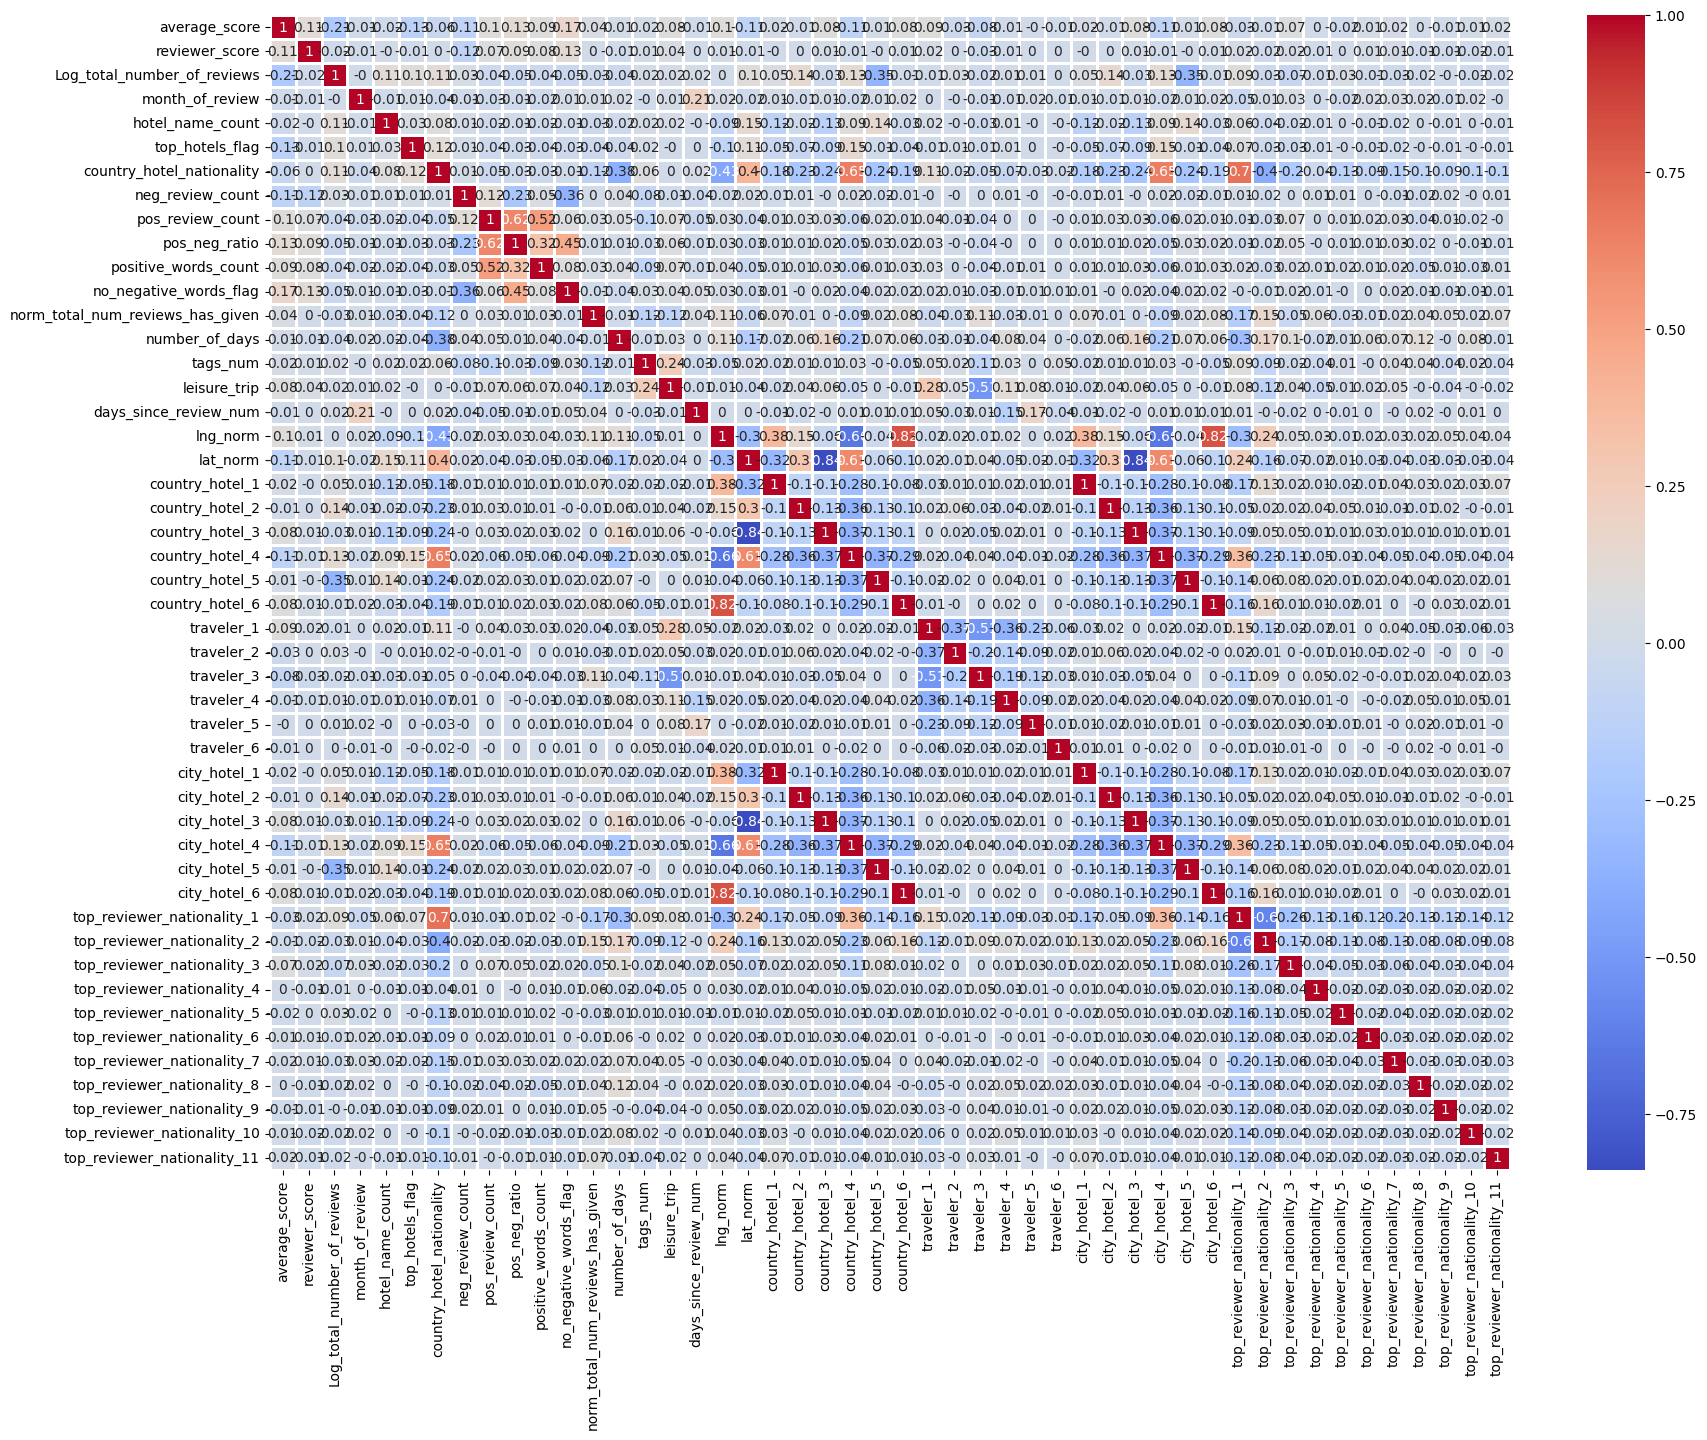

In [218]:
#что получилось после кодирования
fig, ax = plt.subplots(figsize=(20,15))
sns.heatmap(round(data.drop(['sample'], axis=1).corr(numeric_only=True) ,2), annot = True, linewidths=.9, cmap='coolwarm')

ожидаемо появились новые пары признаков с высокой корреляцией, например, как предполагалось ранее - долгота коррелирует с дамми по местунахождения отелей и тп, 
нам необходимо отказаться от признака, в таких парах

In [219]:
data.columns

Index(['average_score', 'sample', 'reviewer_score',
       'Log_total_number_of_reviews', 'month_of_review', 'hotel_name_count',
       'top_hotels_flag', 'country_hotel_nationality', 'neg_review_count',
       'pos_review_count', 'pos_neg_ratio', 'positive_words_count',
       'no_negative_words_flag', 'norm_total_num_reviews_has_given',
       'number_of_days', 'tags_num', 'leisure_trip', 'days_since_review_num',
       'lng_norm', 'lat_norm', 'country_hotel_1', 'country_hotel_2',
       'country_hotel_3', 'country_hotel_4', 'country_hotel_5',
       'country_hotel_6', 'traveler_1', 'traveler_2', 'traveler_3',
       'traveler_4', 'traveler_5', 'traveler_6', 'city_hotel_1',
       'city_hotel_2', 'city_hotel_3', 'city_hotel_4', 'city_hotel_5',
       'city_hotel_6', 'top_reviewer_nationality_1',
       'top_reviewer_nationality_2', 'top_reviewer_nationality_3',
       'top_reviewer_nationality_4', 'top_reviewer_nationality_5',
       'top_reviewer_nationality_6', 'top_reviewer_nation

In [220]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 49 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   average_score                     515431 non-null  float64
 1   sample                            515431 non-null  int64  
 2   reviewer_score                    515431 non-null  float64
 3   Log_total_number_of_reviews       515431 non-null  float64
 4   month_of_review                   515431 non-null  int32  
 5   hotel_name_count                  515431 non-null  int64  
 6   top_hotels_flag                   515431 non-null  int64  
 7   country_hotel_nationality         515431 non-null  int64  
 8   neg_review_count                  515431 non-null  int64  
 9   pos_review_count                  515431 non-null  int64  
 10  pos_neg_ratio                     515431 non-null  float64
 11  positive_words_count              515431 non-null  i

In [221]:
#удалим один из пары признаков с корреляцией выше 0.70
data.drop(['sample'], axis=1).corr().abs().unstack().sort_values(ascending=False).drop_duplicates().head(15)

average_score               average_score                 1.000000
lat_norm                    country_hotel_3               0.844686
city_hotel_6                lng_norm                      0.824958
top_reviewer_nationality_1  country_hotel_nationality     0.700668
city_hotel_4                lng_norm                      0.661208
country_hotel_4             country_hotel_nationality     0.651570
pos_neg_ratio               pos_review_count              0.618291
city_hotel_4                lat_norm                      0.611146
top_reviewer_nationality_2  top_reviewer_nationality_1    0.598635
pos_review_count            positive_words_count          0.524493
traveler_3                  leisure_trip                  0.509046
traveler_1                  traveler_3                    0.505215
pos_neg_ratio               no_negative_words_flag        0.446418
lng_norm                    country_hotel_nationality     0.431423
country_hotel_nationality   top_reviewer_nationality_2    0.40

In [222]:
data = data.drop(['country_hotel_3','country_hotel_6','country_hotel_nationality' ], axis=1)

In [223]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 46 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   average_score                     515431 non-null  float64
 1   sample                            515431 non-null  int64  
 2   reviewer_score                    515431 non-null  float64
 3   Log_total_number_of_reviews       515431 non-null  float64
 4   month_of_review                   515431 non-null  int32  
 5   hotel_name_count                  515431 non-null  int64  
 6   top_hotels_flag                   515431 non-null  int64  
 7   neg_review_count                  515431 non-null  int64  
 8   pos_review_count                  515431 non-null  int64  
 9   pos_neg_ratio                     515431 non-null  float64
 10  positive_words_count              515431 non-null  int64  
 11  no_negative_words_flag            515431 non-null  i

In [224]:
# убираем признаки которые еще не успели обработать, 
# модель на признаках с dtypes "object" обучаться не будет, просто выберим их и удалим
object_columns = [s for s in data.columns if data[s].dtypes == 'object']
data.drop(object_columns, axis = 1, inplace=True)

In [225]:
data.columns

Index(['average_score', 'sample', 'reviewer_score',
       'Log_total_number_of_reviews', 'month_of_review', 'hotel_name_count',
       'top_hotels_flag', 'neg_review_count', 'pos_review_count',
       'pos_neg_ratio', 'positive_words_count', 'no_negative_words_flag',
       'norm_total_num_reviews_has_given', 'number_of_days', 'tags_num',
       'leisure_trip', 'days_since_review_num', 'lng_norm', 'lat_norm',
       'country_hotel_1', 'country_hotel_2', 'country_hotel_4',
       'country_hotel_5', 'traveler_1', 'traveler_2', 'traveler_3',
       'traveler_4', 'traveler_5', 'traveler_6', 'city_hotel_1',
       'city_hotel_2', 'city_hotel_3', 'city_hotel_4', 'city_hotel_5',
       'city_hotel_6', 'top_reviewer_nationality_1',
       'top_reviewer_nationality_2', 'top_reviewer_nationality_3',
       'top_reviewer_nationality_4', 'top_reviewer_nationality_5',
       'top_reviewer_nationality_6', 'top_reviewer_nationality_7',
       'top_reviewer_nationality_8', 'top_reviewer_nationality_9

In [226]:
data_to_model = data

# МОДЕЛИРОВАНИЕ 

### (КОД БЕЗ ИЗМЕНЕНИЙ)

In [227]:
# Теперь выделим тестовую часть
train_data = data_to_model.query('sample == 1').drop(['sample'], axis=1)
test_data = data_to_model.query('sample == 0').drop(['sample'], axis=1)

y = train_data.reviewer_score.values            # наш таргет
X = train_data.drop(['reviewer_score'], axis=1)

In [228]:
# Воспользуемся специальной функцие train_test_split для разбивки тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [229]:
# проверяем
test_data.shape, train_data.shape, X.shape, X_train.shape, X_test.shape

((128935, 45), (386496, 45), (386496, 44), (309196, 44), (77300, 44))

In [230]:
# Импортируем необходимые библиотеки:
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели
from sklearn import metrics # инструменты для оценки точности модели

In [231]:
# Создаём модель (НАСТРОЙКИ НЕ ТРОГАЕМ)
model = RandomForestRegressor(n_estimators=100, verbose=1, n_jobs=-1, random_state=RANDOM_SEED)

In [232]:
# Обучаем модель на тестовом наборе данных
model.fit(X_train, y_train)

# Используем обученную модель для предсказания рейтинга ресторанов в тестовой выборке.
# Предсказанные значения записываем в переменную y_pred
y_pred = model.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.3min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished


In [233]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они в среднем отличаются
# Метрика называется Mean Absolute Error (MAE) и показывает среднее отклонение предсказанных значений от фактических.
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))

#MAE: 0.9823059147830514 базовый сценарий
#MAE: 0.9495966311650208
#MAE: 0.9472851082923458
#MAE: 0.9589671488929493 не убрала дубликаты, заменила выбосы на мин значения (1)
# AE: 0.9530036247158211 заменила выброс 5.2 на мин 6.4(2)
# MAE: 0.9527111769340859 ввела признак кол-во слов в наименовании отеля (3)
# MAE: 0.9527445192518783 заменила значения макс  в поле has_been_given(4)
#MAE: 0.9529323763575558 заменила  has_been_given на разницу со средним(5)
#MAE: 0.9905671864952043 без категориальных признаков
# MAE: 0.9453244748474456 убрала дубликаты, добавила 2 признака, месяц отзыва и теплый/холодный сезон (7)
#MAE: 0.9434435015092709 внесла правки с учетом комментария ментора (8)
#MAE: 0.9445234842604567 добавила 2 переменные (квартал и путешествие-отпуск)  (9)
#MAE: 0.9465504592188749  data.drop(['trip_type_3','traveler_4', 'traveler_5', 'traveler_6'], axis=1)    (10)
#MAE: 0.9436655451857323 добавлен показатель (11) 
#MAE: 0.9382451101459987  добавила показатель, который подсчитывает кол-во положительных слов в отзыве(12)
#MAE: 0.9331175215302159 поменяла показатель, 1кв убрала, вернула месяц отзыва (13)
#MAE: 0.9210458480872294 добавили признак отсутствия значимого отрицательного отзыва по типам слов (14) - пока лучшая модель
#MAE: 0.92117652692047 добавила новый признак *принадлежность к сети отелей* (15)
#MAE: 0.9166717577157638 нормализация признаков и новые признаки (16)

MAE: 0.9166717577157638


In [234]:
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

#MAPE: 0.13784769595130533
#MAPE: 0.13757834771350094
#MAPE: 0.1382851222454504  (1)
#MAPE: 0.13707409673985393  (2)
# MAPE: 0.13708516275899585 (3)
# MAPE: 0.13707489457420158 (4)
# MAPE: 0.13710310141786772 (5)
# MAPE: 0.14258873098434582 (6)
# MAPE: 0.13654202592726686 (7)
#MAPE: 0.13642504458213275 (8)
#MAPE: 0.13657052655967622 (9)
#MAPE: 0.1367933044431343 (10)
#MAPE: 0.136423082120557 (11)
#MAPE: 0.13550068401924711 (12)
#MAPE: 0.13458489672670051 (13)
#MAPE: 0.13287221958765408 (14)-пока лучшая модель
#MAPE: 0.13290205514204442 (15)
#MAPE: 0.13237005121322365 (16)

MAPE: 0.13237005121322365


<Axes: >

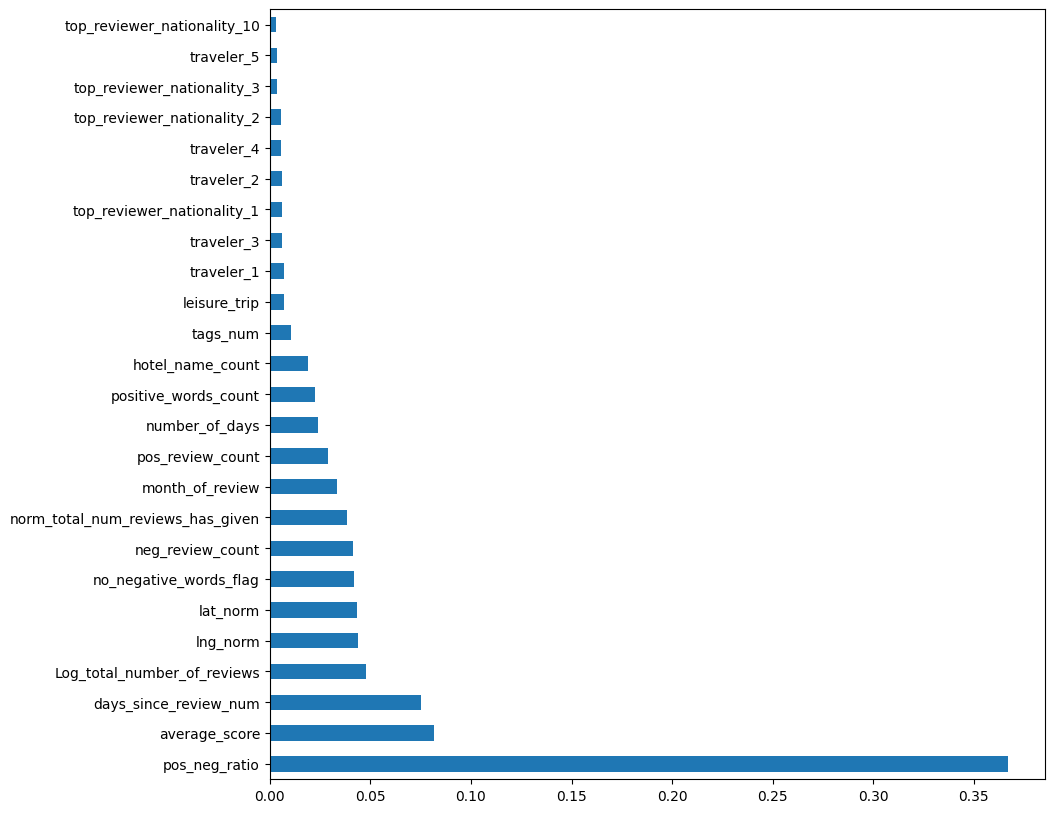

In [243]:
# в RandomForestRegressor есть возможность вывести самые важные признаки для модели
plt.rcParams['figure.figsize'] = (10,10)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(25).plot(kind='barh')

In [236]:
test_data.sample(10)

,average_score,reviewer_score,Log_total_number_of_reviews,month_of_review,hotel_name_count,top_hotels_flag,neg_review_count,pos_review_count,pos_neg_ratio,positive_words_count,...,top_reviewer_nationality_2,top_reviewer_nationality_3,top_reviewer_nationality_4,top_reviewer_nationality_5,top_reviewer_nationality_6,top_reviewer_nationality_7,top_reviewer_nationality_8,top_reviewer_nationality_9,top_reviewer_nationality_10,top_reviewer_nationality_11
102651,8.6,0.0,8.200563,8,4,0,2,14,4.666667,3,...,0,0,0,0,0,1,0,0,0,0
86978,8.3,0.0,7.569928,9,5,0,45,10,0.217391,1,...,1,0,0,0,0,0,0,0,0,0
121380,7.6,0.0,5.703782,2,2,0,48,69,1.408163,6,...,1,0,0,0,0,0,0,0,0,0
99687,8.1,0.0,8.265393,12,5,0,9,22,2.200000,1,...,1,0,0,0,0,0,0,0,0,0
10004,8.1,0.0,7.225481,6,3,0,2,1,0.333333,0,...,0,0,0,0,1,0,0,0,0,0
27459,9.1,0.0,8.452548,2,3,0,2,25,8.333333,0,...,0,0,0,1,0,0,0,0,0,0
109334,8.0,0.0,7.444249,4,3,0,7,2,0.250000,0,...,0,0,0,0,0,0,0,0,0,0
28762,8.1,0.0,8.759826,3,3,0,41,57,1.357143,4,...,1,0,0,0,0,0,0,0,0,0
80039,9.1,0.0,5.988961,12,3,0,2,15,5.000000,1,...,1,0,0,0,0,0,0,0,0,0
109296,8.6,0.0,8.248791,6,4,0,2,19,6.333333,4,...,0,0,0,0,0,0,0,0,0,0


In [237]:
test_data = test_data.drop(['reviewer_score'], axis=1)

In [238]:
sample_submission

,reviewer_score,id
0,8.328,488440
1,7.886,274649
2,8.225,374688
3,9.598,404352
4,9.666,451596
...,...,...
128930,8.652,495812
128931,7.902,315577
128932,8.189,511968
128933,9.574,303386


In [239]:
predict_submission = model.predict(test_data)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.2s finished


In [240]:
predict_submission

array([8.49 , 7.616, 8.339, ..., 7.804, 9.503, 7.886])

In [241]:
list(sample_submission)

['reviewer_score', 'id']

In [242]:
sample_submission['reviewer_score'] = predict_submission
sample_submission.to_csv('submission.csv', index=False)
sample_submission.head(10)

,reviewer_score,id
0,8.490,488440
1,7.616,274649
2,8.339,374688
3,9.545,404352
4,9.630,451596
5,8.063,302161
6,7.730,317079
7,7.725,13963
8,8.711,159785
9,7.078,195089
